# USAspending.gov GAN and Lightweight Extended DPoS Pipeline

The original code is preserved. Only the dataset-loading block was changed to read `GFunddata.csv` from Google Drive.

In [1]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 1 — Install Required Packages
# ═══════════════════════════════════════════════════════════════
!pip -q install pandas numpy scikit-learn tensorflow matplotlib

In [2]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 2 — Import Libraries and Configure Reproducibility
# ═══════════════════════════════════════════════════════════════
import os
import gc
import json
import time
import random
import hashlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

warnings.filterwarnings("ignore")

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [3]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 3 — Load USAspending.gov CSV Dataset from Google Drive
# ═══════════════════════════════════════════════════════════════
from google.colab import drive

drive.mount("/content/drive")

GOOGLE_DRIVE_FOLDER_LINK = (
    "https://drive.google.com/drive/folders/"
    "1v7UgRC2BGgk6F9gVsGdwP5DE6KhV39IQ"
)

DATASET_PATH = "/content/drive/MyDrive/p-83/GDataset/GFunddata.csv"

print("Google Drive folder:", GOOGLE_DRIVE_FOLDER_LINK)
print("Dataset path:", DATASET_PATH)

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(
        f"Dataset not found at: {DATASET_PATH}\n"
        "Confirm that GFunddata.csv is stored in "
        "My Drive/p-83/GDataset/."
    )

df = pd.read_csv(
    DATASET_PATH,
    low_memory=False,
    on_bad_lines="skip"
)

print("Original dataset shape:", df.shape)

print("\nDataset columns:")
for index, column in enumerate(df.columns, start=1):
    print(f"{index:03d}. {column}")

display(df.head())

Mounted at /content/drive
Google Drive folder: https://drive.google.com/drive/folders/1v7UgRC2BGgk6F9gVsGdwP5DE6KhV39IQ
Dataset path: /content/drive/MyDrive/p-83/GDataset/GFunddata.csv
Original dataset shape: (1000000, 297)

Dataset columns:
001. contract_transaction_unique_key
002. contract_award_unique_key
003. award_id_piid
004. modification_number
005. transaction_number
006. parent_award_agency_id
007. parent_award_agency_name
008. parent_award_id_piid
009. parent_award_modification_number
010. federal_action_obligation
011. total_dollars_obligated
012. total_outlayed_amount_for_overall_award
013. base_and_exercised_options_value
014. current_total_value_of_award
015. base_and_all_options_value
016. potential_total_value_of_award
017. disaster_emergency_fund_codes_for_overall_award
018. outlayed_amount_from_COVID-19_supplementals_for_overall_award
019. obligated_amount_from_COVID-19_supplementals_for_overall_award
020. outlayed_amount_from_IIJA_supplemental_for_overall_award
021. 

,contract_transaction_unique_key,contract_award_unique_key,award_id_piid,modification_number,transaction_number,parent_award_agency_id,parent_award_agency_name,parent_award_id_piid,parent_award_modification_number,federal_action_obligation,...,highly_compensated_officer_2_amount,highly_compensated_officer_3_name,highly_compensated_officer_3_amount,highly_compensated_officer_4_name,highly_compensated_officer_4_amount,highly_compensated_officer_5_name,highly_compensated_officer_5_amount,usaspending_permalink,initial_report_date,last_modified_date
0,4732_4732_47QSSC26F014D_0_GS03FGA010_0,CONT_AWD_47QSSC26F014D_4732_GS03FGA010_4732,47QSSC26F014D,0,0.0,4732,FEDERAL ACQUISITION SERVICE,GS03FGA010,PW0006,116.18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.usaspending.gov/award/CONT_AWD_47Q...,2025-10-06 05:37:39+00,2025-10-06 05:37:40+00
1,4732_4732_47QSSC26F04CK_0_47QSEA23D0044_0,CONT_AWD_47QSSC26F04CK_4732_47QSEA23D0044_4732,47QSSC26F04CK,0,0.0,4732,FEDERAL ACQUISITION SERVICE,47QSEA23D0044,0,170.85,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.usaspending.gov/award/CONT_AWD_47Q...,2025-10-05 16:04:56+00,2025-10-05 16:04:57+00
2,4732_4732_47QSSC26F04FB_0_47QSHA21A000D_0,CONT_AWD_47QSSC26F04FB_4732_47QSHA21A000D_4732,47QSSC26F04FB,0,0.0,4732,FEDERAL ACQUISITION SERVICE,47QSHA21A000D,PS0010,1.05,...,184189.0,JEFFREY PRIMEAU,100795.0,PATRICK TREVISAN,91799.0,ANDREW BITER,87208.0,https://www.usaspending.gov/award/CONT_AWD_47Q...,2025-10-05 09:41:15+00,2025-10-05 09:41:15+00
3,4732_4732_47QSSC26F0781_0_47QSWA22D0009_0,CONT_AWD_47QSSC26F0781_4732_47QSWA22D0009_4732,47QSSC26F0781,0,0.0,4732,FEDERAL ACQUISITION SERVICE,47QSWA22D0009,0,27.84,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.usaspending.gov/award/CONT_AWD_47Q...,2025-10-06 01:03:34+00,2025-10-06 01:03:35+00
4,4732_4732_47QSSC26F07BB_0_47QSWA21D007B_0,CONT_AWD_47QSSC26F07BB_4732_47QSWA21D007B_4732,47QSSC26F07BB,0,0.0,4732,FEDERAL ACQUISITION SERVICE,47QSWA21D007B,PA0019,1820.65,...,131958.0,KRISTOPHER DELOSUA,107549.0,ROBERTA FREEMAN,86119.0,CHRISTIAN SCOTT,82422.0,https://www.usaspending.gov/award/CONT_AWD_47Q...,2025-10-07 01:01:11+00,2025-10-07 01:01:12+00


In [4]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 4 — Automatic USAspending Column Mapping
# ═══════════════════════════════════════════════════════════════
COLUMN_CANDIDATES = {
    "project_id": [
        "contract_award_unique_key",
        "assistance_award_unique_key",
        "generated_unique_award_id",
        "award_id_piid",
        "award_id_fain",
        "award_id_uri"
    ],

    "project_name": [
        "award_description",
        "transaction_description",
        "product_or_service_code_description",
        "cfda_title"
    ],

    "finance_ministry": [
        "funding_agency_name",
        "awarding_agency_name",
        "funding_sub_agency_name",
        "awarding_sub_agency_name"
    ],

    "treasury": [
        "treasury_accounts_funding_this_award",
        "federal_accounts_funding_this_award",
        "treasury_account_symbol",
        "federal_account_name"
    ],

    "city_corporation": [
        "recipient_city_name",
        "recipient_county_name",
        "recipient_state_name",
        "place_of_performance_city_name",
        "place_of_performance_county_name",
        "place_of_performance_state_name"
    ],

    "builder": [
        "recipient_name",
        "recipient_parent_name",
        "recipient_uei",
        "recipient_duns"
    ],

    "budget": [
        "total_obligated_amount",
        "current_total_value_of_award",
        "potential_total_value_of_award",
        "base_and_all_options_value",
        "federal_action_obligation",
        "total_outlayed_amount_for_overall_award"
    ],

    "transaction_amount": [
        "federal_action_obligation",
        "current_total_value_of_award",
        "total_obligated_amount",
        "total_outlayed_amount_for_overall_award"
    ],

    "date": [
        "action_date",
        "period_of_performance_start_date",
        "period_of_performance_current_end_date",
        "last_modified_date"
    ],

    "award_type": [
        "award_type",
        "award_type_code",
        "contract_award_type",
        "type"
    ],

    "location": [
        "primary_place_of_performance_city_name",
        "place_of_performance_city_name",
        "recipient_city_name",
        "recipient_state_name"
    ]
}


def normalize_column_name(name):
    """Normalize a column name for robust matching."""
    return str(name).strip().lower().replace(" ", "_")


normalized_lookup = {
    normalize_column_name(column): column
    for column in df.columns
}


def find_matching_column(candidate_names):
    """Return the first matching original dataset column."""
    for candidate in candidate_names:
        normalized_candidate = normalize_column_name(candidate)

        if normalized_candidate in normalized_lookup:
            return normalized_lookup[normalized_candidate]

    return None


selected_columns = {
    logical_name: find_matching_column(candidates)
    for logical_name, candidates in COLUMN_CANDIDATES.items()
}

print("Selected USAspending column mapping:\n")

for logical_name, selected_column in selected_columns.items():
    print(f"{logical_name:22s} -> {selected_column}")

Selected USAspending column mapping:

project_id             -> contract_award_unique_key
project_name           -> transaction_description
finance_ministry       -> funding_agency_name
treasury               -> treasury_accounts_funding_this_award
city_corporation       -> recipient_city_name
builder                -> recipient_name
budget                 -> current_total_value_of_award
transaction_amount     -> federal_action_obligation
date                   -> action_date
award_type             -> award_type
location               -> primary_place_of_performance_city_name


In [5]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 5 — Build the Government Budget Management Dataset
# ═══════════════════════════════════════════════════════════════
def get_column_or_default(source_df, column_name, default_value):
    if column_name is not None:
        return source_df[column_name].copy()

    return pd.Series(
        [default_value] * len(source_df),
        index=source_df.index
    )


data = pd.DataFrame(index=df.index)

data["Project_ID"] = get_column_or_default(
    df,
    selected_columns["project_id"],
    None
)

missing_project_ids = data["Project_ID"].isna() | (
    data["Project_ID"].astype(str).str.strip() == ""
)

data.loc[missing_project_ids, "Project_ID"] = [
    f"PRJ-{index:08d}"
    for index in data.index[missing_project_ids]
]

data["Project_Name"] = get_column_or_default(
    df,
    selected_columns["project_name"],
    "Government Project"
)

data["Finance_Ministry"] = get_column_or_default(
    df,
    selected_columns["finance_ministry"],
    "Federal Funding Agency"
)

data["Treasury"] = get_column_or_default(
    df,
    selected_columns["treasury"],
    "United States Treasury"
)

data["City_Corporation"] = get_column_or_default(
    df,
    selected_columns["city_corporation"],
    "Local Government Authority"
)

data["Builder"] = get_column_or_default(
    df,
    selected_columns["builder"],
    "Government Contractor"
)

data["Award_Type"] = get_column_or_default(
    df,
    selected_columns["award_type"],
    "Unknown Award Type"
)

data["Project_Location"] = get_column_or_default(
    df,
    selected_columns["location"],
    "Unknown Location"
)

data["Action_Date"] = get_column_or_default(
    df,
    selected_columns["date"],
    "Unknown Date"
)

if selected_columns["budget"] is None:
    raise ValueError(
        "No suitable budget column was detected. "
        "Check the printed dataset columns and update COLUMN_CANDIDATES."
    )

data["Budget"] = pd.to_numeric(
    df[selected_columns["budget"]],
    errors="coerce"
)

if selected_columns["transaction_amount"] is not None:
    data["Transaction_Amount"] = pd.to_numeric(
        df[selected_columns["transaction_amount"]],
        errors="coerce"
    )
else:
    data["Transaction_Amount"] = data["Budget"]


# Replace infinite values
data["Budget"] = data["Budget"].replace([np.inf, -np.inf], np.nan)
data["Transaction_Amount"] = data["Transaction_Amount"].replace(
    [np.inf, -np.inf],
    np.nan
)

# Missing amount handling
data["Budget"] = data["Budget"].fillna(0)
data["Transaction_Amount"] = data["Transaction_Amount"].fillna(
    data["Budget"]
)

# Financial reversals may appear as negative obligations.
# Absolute values are used for blockchain simulation.
data["Budget"] = data["Budget"].abs()
data["Transaction_Amount"] = data["Transaction_Amount"].abs()

# Remove zero-budget records
data = data[data["Budget"] > 0].copy()

# Fill categorical missing values
categorical_columns = [
    "Project_ID",
    "Project_Name",
    "Finance_Ministry",
    "Treasury",
    "City_Corporation",
    "Builder",
    "Award_Type",
    "Project_Location",
    "Action_Date"
]

for column in categorical_columns:
    data[column] = (
        data[column]
        .fillna("Unknown")
        .astype(str)
        .str.strip()
    )

# Remove duplicate project-transaction records
data = data.drop_duplicates(
    subset=["Project_ID", "Transaction_Amount"],
    keep="first"
).reset_index(drop=True)

print("Processed dataset shape:", data.shape)
display(data.head())

Processed dataset shape: (916319, 11)


,Project_ID,Project_Name,Finance_Ministry,Treasury,City_Corporation,Builder,Award_Type,Project_Location,Action_Date,Budget,Transaction_Amount
0,CONT_AWD_47QSSC26F014D_4732_GS03FGA010_4732,"BOARD,MARKER",General Services Administration,047-X-4534-001,ALEXANDRIA,NATIONAL INDUSTRIES FOR THE BLIND,DELIVERY ORDER,SEATTLE,2025-10-02,116.18,116.18
1,CONT_AWD_47QSSC26F04CK_4732_47QSEA23D0044_4732,"CARTRIDGE, TONER: ITEM NAME CARTRIDGE, TONER I...",General Services Administration,047-X-4534-001,GREENACRES,SUPPLIES NOW INC,DELIVERY ORDER,GREENACRES,2025-10-03,170.85,170.85
2,CONT_AWD_47QSSC26F04FB_4732_47QSHA21A000D_4732,"KEY,SOCKET HEAD SCREW SNAP-ON INC P/N: AWM6D",General Services Administration,047-X-4534-001,WARREN,"WRIGHT TOOL COMPANY, LLC",BPA CALL,WARREN,2025-10-03,1.05,1.05
3,CONT_AWD_47QSSC26F0781_4732_47QSWA22D0009_4732,"BRUSH,WIRE,SCRATCH",General Services Administration,047-X-4534-001,ALEXANDRIA,NATIONAL INDUSTRIES FOR THE BLIND,DELIVERY ORDER,ALEXANDRIA,2025-10-05,27.84,27.84
4,CONT_AWD_47QSSC26F07BB_4732_47QSWA21D007B_4732,SANTIZ ENTERPRISES-70404,General Services Administration,047-X-4534-001,FREDERICKSBURG,"SANITZ ENTERPRISES, INC.",DELIVERY ORDER,WILLOW CITY,2025-10-06,1820.65,1820.65


In [6]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 6 — Feature Engineering and Risk-Label Construction
# ═══════════════════════════════════════════════════════════════
# USAspending does not provide a direct fraud label.
# Therefore, a reproducible proxy-risk label is generated using
# unusual transaction and budget characteristics.

data["Action_Date_Parsed"] = pd.to_datetime(
    data["Action_Date"],
    errors="coerce"
)

data["Action_Year"] = data["Action_Date_Parsed"].dt.year.fillna(0).astype(int)
data["Action_Month"] = data["Action_Date_Parsed"].dt.month.fillna(0).astype(int)
data["Action_Day"] = data["Action_Date_Parsed"].dt.day.fillna(0).astype(int)

data["Budget_Log"] = np.log1p(data["Budget"])
data["Transaction_Log"] = np.log1p(data["Transaction_Amount"])

data["Transaction_Budget_Ratio"] = (
    data["Transaction_Amount"] /
    data["Budget"].replace(0, np.nan)
).replace([np.inf, -np.inf], np.nan).fillna(0)

data["Recipient_Name_Length"] = data["Builder"].str.len()
data["Project_Name_Length"] = data["Project_Name"].str.len()

budget_high = data["Budget"].quantile(0.97)
transaction_high = data["Transaction_Amount"].quantile(0.97)

ratio_low = data["Transaction_Budget_Ratio"].quantile(0.01)
ratio_high = data["Transaction_Budget_Ratio"].quantile(0.99)

data["Risk_Label"] = (
    (data["Budget"] >= budget_high) |
    (data["Transaction_Amount"] >= transaction_high) |
    (data["Transaction_Budget_Ratio"] <= ratio_low) |
    (data["Transaction_Budget_Ratio"] >= ratio_high)
).astype(int)

print("Risk-label distribution:")
print(data["Risk_Label"].value_counts())

print("\nRisk-label percentage:")
print(data["Risk_Label"].value_counts(normalize=True).mul(100).round(2))

Risk-label distribution:
Risk_Label
1    860114
0     56205
Name: count, dtype: int64

Risk-label percentage:
Risk_Label
1    93.87
0     6.13
Name: proportion, dtype: float64


In [7]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 7 — Prepare Machine-Learning Features
# ═══════════════════════════════════════════════════════════════
feature_columns = [
    "Project_Name",
    "Finance_Ministry",
    "Treasury",
    "City_Corporation",
    "Builder",
    "Award_Type",
    "Project_Location",
    "Budget_Log",
    "Transaction_Log",
    "Transaction_Budget_Ratio",
    "Action_Year",
    "Action_Month",
    "Action_Day",
    "Recipient_Name_Length",
    "Project_Name_Length"
]

X = data[feature_columns].copy()
y = data["Risk_Label"].astype(int).copy()

encoders = {}

for column in X.select_dtypes(include=["object"]).columns:
    encoder = LabelEncoder()

    X[column] = encoder.fit_transform(
        X[column].fillna("Unknown").astype(str)
    )

    encoders[column] = encoder

X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
display(X.head())

Feature matrix shape: (916319, 15)
Target shape: (916319,)


,Project_Name,Finance_Ministry,Treasury,City_Corporation,Builder,Award_Type,Project_Location,Budget_Log,Transaction_Log,Transaction_Budget_Ratio,Action_Year,Action_Month,Action_Day,Recipient_Name_Length,Project_Name_Length
0,496441,46,5761,81,22583,2,4608,4.763711,4.763711,1.0,2025,10,2,33,12
1,501455,46,5761,2279,31000,2,2061,5.146622,5.146622,1.0,2025,10,3,16,250
2,553476,46,5761,6148,35876,0,5291,0.717840,0.717840,1.0,2025,10,3,24,44
3,498273,46,5761,81,22583,2,64,3.361763,3.361763,1.0,2025,10,5,33,18
4,597151,46,5761,2038,28335,2,5512,7.507498,7.507498,1.0,2025,10,6,24,24


In [8]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 8 — Single Stratified Train/Test Split
# 5-Fold Cross-Validation Has Been Removed
# ═══════════════════════════════════════════════════════════════
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

y_train = y_train.to_numpy(dtype=np.int32)
y_test = y_test.to_numpy(dtype=np.int32)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining label distribution:")
print(pd.Series(y_train).value_counts())

print("\nTesting label distribution:")
print(pd.Series(y_test).value_counts())

Training samples: 733055
Testing samples: 183264

Training label distribution:
1    688091
0     44964
Name: count, dtype: int64

Testing label distribution:
1    172023
0     11241
Name: count, dtype: int64


In [9]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 9 — GAN Models for Minority-Class Data Generation
# ═══════════════════════════════════════════════════════════════
def build_generator(latent_dimension, output_dimension):
    generator = models.Sequential(
        [
            layers.Input(shape=(latent_dimension,)),
            layers.Dense(64),
            layers.LeakyReLU(negative_slope=0.2),
            layers.BatchNormalization(),

            layers.Dense(128),
            layers.LeakyReLU(negative_slope=0.2),
            layers.BatchNormalization(),

            layers.Dense(output_dimension, activation="linear")
        ],
        name="Minority_Generator"
    )

    return generator


def build_discriminator(input_dimension):
    discriminator = models.Sequential(
        [
            layers.Input(shape=(input_dimension,)),
            layers.Dense(128),
            layers.LeakyReLU(negative_slope=0.2),
            layers.Dropout(0.20),

            layers.Dense(64),
            layers.LeakyReLU(negative_slope=0.2),
            layers.Dropout(0.20),

            layers.Dense(1, activation="sigmoid")
        ],
        name="Minority_Discriminator"
    )

    discriminator.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.0002,
            beta_1=0.5
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return discriminator

In [10]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 10 — GAN-Based Class-Imbalance Handling
# ═══════════════════════════════════════════════════════════════
def gan_oversample(
    X_input,
    y_input,
    latent_dimension=32,
    epochs=200,
    batch_size=64,
    verbose_interval=50
):
    X_input = np.asarray(X_input, dtype=np.float32)
    y_input = np.asarray(y_input, dtype=np.int32)

    labels, counts = np.unique(y_input, return_counts=True)

    if len(labels) < 2:
        print("Only one class is available. GAN oversampling skipped.")
        return X_input, y_input, None

    minority_class = labels[np.argmin(counts)]
    majority_class = labels[np.argmax(counts)]

    X_minority = X_input[y_input == minority_class]
    X_majority = X_input[y_input == majority_class]

    number_to_generate = len(X_majority) - len(X_minority)

    print("Minority class:", minority_class)
    print("Majority class:", majority_class)
    print("Minority samples:", len(X_minority))
    print("Majority samples:", len(X_majority))
    print("Synthetic samples required:", number_to_generate)

    if number_to_generate <= 0:
        print("Training data are already balanced.")
        return X_input, y_input, None

    input_dimension = X_input.shape[1]

    generator = build_generator(
        latent_dimension,
        input_dimension
    )

    discriminator = build_discriminator(input_dimension)

    discriminator.trainable = False

    noise_input = layers.Input(shape=(latent_dimension,))
    generated_features = generator(noise_input)
    validity = discriminator(generated_features)

    combined_gan = models.Model(
        noise_input,
        validity,
        name="Minority_GAN"
    )

    combined_gan.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.0002,
            beta_1=0.5
        ),
        loss="binary_crossentropy"
    )

    discriminator_loss_history = []
    generator_loss_history = []

    effective_batch_size = min(batch_size, len(X_minority))

    for epoch in range(1, epochs + 1):
        # Train discriminator with real minority samples
        real_indices = np.random.randint(
            0,
            len(X_minority),
            effective_batch_size
        )

        real_samples = X_minority[real_indices]

        noise = np.random.normal(
            0,
            1,
            size=(effective_batch_size, latent_dimension)
        ).astype(np.float32)

        generated_samples = generator.predict(
            noise,
            verbose=0
        )

        real_targets = np.ones(
            (effective_batch_size, 1),
            dtype=np.float32
        ) * 0.9

        fake_targets = np.zeros(
            (effective_batch_size, 1),
            dtype=np.float32
        )

        discriminator.trainable = True

        discriminator_real_loss = discriminator.train_on_batch(
            real_samples,
            real_targets
        )

        discriminator_fake_loss = discriminator.train_on_batch(
            generated_samples,
            fake_targets
        )

        discriminator_loss = 0.5 * (
            float(discriminator_real_loss[0]) +
            float(discriminator_fake_loss[0])
        )

        # Train generator
        discriminator.trainable = False

        noise = np.random.normal(
            0,
            1,
            size=(effective_batch_size, latent_dimension)
        ).astype(np.float32)

        misleading_targets = np.ones(
            (effective_batch_size, 1),
            dtype=np.float32
        )

        generator_loss = combined_gan.train_on_batch(
            noise,
            misleading_targets
        )

        discriminator_loss_history.append(discriminator_loss)
        generator_loss_history.append(float(generator_loss))

        if epoch == 1 or epoch % verbose_interval == 0:
            print(
                f"Epoch {epoch:4d}/{epochs} | "
                f"D Loss: {discriminator_loss:.4f} | "
                f"G Loss: {float(generator_loss):.4f}"
            )

    generation_noise = np.random.normal(
        0,
        1,
        size=(number_to_generate, latent_dimension)
    ).astype(np.float32)

    synthetic_minority_samples = generator.predict(
        generation_noise,
        batch_size=1024,
        verbose=0
    )

    # Restrict generated values to the training-data range
    feature_minimums = X_minority.min(axis=0)
    feature_maximums = X_minority.max(axis=0)

    synthetic_minority_samples = np.clip(
        synthetic_minority_samples,
        feature_minimums,
        feature_maximums
    )

    X_balanced = np.vstack(
        [X_input, synthetic_minority_samples]
    )

    y_balanced = np.concatenate(
        [
            y_input,
            np.full(
                number_to_generate,
                minority_class,
                dtype=np.int32
            )
        ]
    )

    shuffled_indices = np.random.permutation(len(X_balanced))

    X_balanced = X_balanced[shuffled_indices]
    y_balanced = y_balanced[shuffled_indices]

    gan_history = {
        "discriminator_loss": discriminator_loss_history,
        "generator_loss": generator_loss_history,
        "minority_class": int(minority_class),
        "generated_samples": int(number_to_generate)
    }

    return X_balanced, y_balanced, gan_history


X_train_balanced, y_train_balanced, gan_history = gan_oversample(
    X_train,
    y_train,
    latent_dimension=32,
    epochs=200,
    batch_size=64
)

print("\nBalanced training distribution:")
print(pd.Series(y_train_balanced).value_counts())

Minority class: 0
Majority class: 1
Minority samples: 44964
Majority samples: 688091
Synthetic samples required: 643127
Epoch    1/200 | D Loss: 0.6637 | G Loss: 0.6539
Epoch   50/200 | D Loss: 0.6107 | G Loss: 0.5583
Epoch  100/200 | D Loss: 0.5984 | G Loss: 0.6113
Epoch  150/200 | D Loss: 0.5936 | G Loss: 0.7243
Epoch  200/200 | D Loss: 0.5996 | G Loss: 0.7835

Balanced training distribution:
1    688091
0    688091
Name: count, dtype: int64


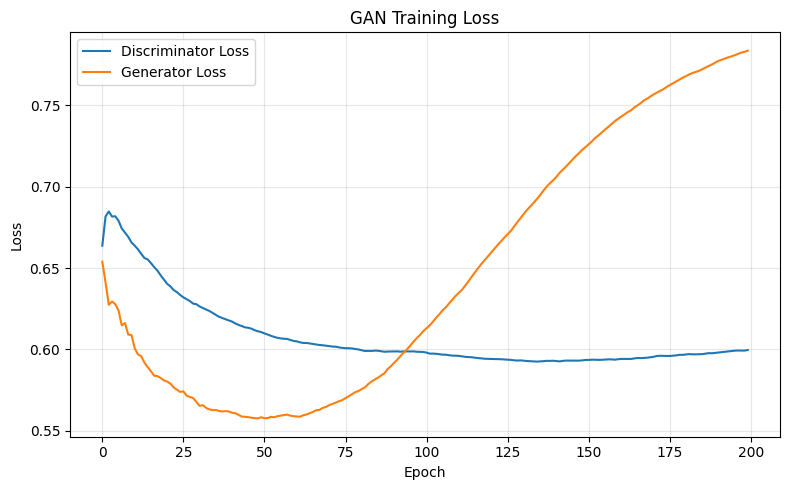

In [11]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 11 — GAN Training-Loss Visualization
# ═══════════════════════════════════════════════════════════════
if gan_history is not None:
    plt.figure(figsize=(8, 5))

    plt.plot(
        gan_history["discriminator_loss"],
        label="Discriminator Loss"
    )

    plt.plot(
        gan_history["generator_loss"],
        label="Generator Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("GAN Training Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [12]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 12 — Train and Evaluate the Classification Model
# ═══════════════════════════════════════════════════════════════
classifier = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=4,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1
)

classification_start_time = time.perf_counter()

classifier.fit(
    X_train_balanced,
    y_train_balanced
)

training_time = time.perf_counter() - classification_start_time

prediction_start_time = time.perf_counter()

y_prediction = classifier.predict(X_test)
y_probability = classifier.predict_proba(X_test)[:, 1]

prediction_time = time.perf_counter() - prediction_start_time

accuracy = accuracy_score(y_test, y_prediction)
precision = precision_score(
    y_test,
    y_prediction,
    zero_division=0
)
recall = recall_score(
    y_test,
    y_prediction,
    zero_division=0
)
f1 = f1_score(
    y_test,
    y_prediction,
    zero_division=0
)

try:
    roc_auc = roc_auc_score(y_test, y_probability)
except ValueError:
    roc_auc = np.nan

ml_results = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1-Score",
            "ROC-AUC",
            "Training Time (s)",
            "Prediction Time (s)"
        ],
        "Value": [
            accuracy,
            precision,
            recall,
            f1,
            roc_auc,
            training_time,
            prediction_time
        ]
    }
)

display(ml_results)

print("\nClassification Report:\n")
print(
    classification_report(
        y_test,
        y_prediction,
        digits=4,
        zero_division=0
    )
)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_prediction))

,Metric,Value
0,Accuracy,0.999302
1,Precision,0.999895
2,Recall,0.999361
3,F1-Score,0.999628
4,ROC-AUC,0.999946
5,Training Time (s),145.553972
6,Prediction Time (s),0.619283



Classification Report:

              precision    recall  f1-score   support

           0     0.9903    0.9984    0.9943     11241
           1     0.9999    0.9994    0.9996    172023

    accuracy                         0.9993    183264
   macro avg     0.9951    0.9989    0.9970    183264
weighted avg     0.9993    0.9993    0.9993    183264

Confusion Matrix:
[[ 11223     18]
 [   110 171913]]


In [13]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 13 — Lightweight Extended DPoS Blockchain Components
# ═══════════════════════════════════════════════════════════════
PROOF_TYPE = "Extended Delegated Proof of Stake (DPoS)"


def stable_hash(payload):
    """Generate a compact deterministic SHA-256 hash."""
    encoded_payload = json.dumps(
        payload,
        sort_keys=True,
        separators=(",", ":"),
        default=str
    ).encode("utf-8")

    return hashlib.sha256(encoded_payload).hexdigest()


class LightweightTransaction:
    """
    Memory-efficient blockchain transaction using __slots__.
    """

    __slots__ = (
        "transaction_id",
        "function_name",
        "sender",
        "receiver",
        "project_id",
        "amount",
        "gas_used",
        "timestamp",
        "signature"
    )

    def __init__(
        self,
        function_name,
        sender,
        receiver,
        project_id,
        amount,
        gas_used
    ):
        self.function_name = str(function_name)
        self.sender = str(sender)
        self.receiver = str(receiver)
        self.project_id = str(project_id)
        self.amount = float(amount)
        self.gas_used = int(gas_used)
        self.timestamp = time.time()

        transaction_payload = {
            "function_name": self.function_name,
            "sender": self.sender,
            "receiver": self.receiver,
            "project_id": self.project_id,
            "amount": self.amount,
            "timestamp": self.timestamp
        }

        self.transaction_id = stable_hash(transaction_payload)

        # Lightweight simulated digital signature
        self.signature = stable_hash(
            {
                "transaction_id": self.transaction_id,
                "sender": self.sender
            }
        )

    def to_dict(self):
        return {
            "transaction_id": self.transaction_id,
            "function_name": self.function_name,
            "sender": self.sender,
            "receiver": self.receiver,
            "project_id": self.project_id,
            "amount": self.amount,
            "gas_used": self.gas_used,
            "timestamp": self.timestamp,
            "signature": self.signature
        }


class DPoSDelegate:
    """
    Delegate candidate participating in Extended DPoS.
    """

    __slots__ = (
        "delegate_id",
        "stake",
        "reputation",
        "availability",
        "blocks_produced"
    )

    def __init__(
        self,
        delegate_id,
        stake,
        reputation,
        availability
    ):
        self.delegate_id = str(delegate_id)
        self.stake = float(stake)
        self.reputation = float(reputation)
        self.availability = float(availability)
        self.blocks_produced = 0

    @property
    def voting_score(self):
        """
        Extended DPoS score combining:
        50% stake, 30% reputation and 20% availability.
        """
        return (
            0.50 * self.stake +
            0.30 * self.reputation +
            0.20 * self.availability
        )

In [14]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 14 — Lightweight Block and Extended DPoS Consensus
# ═══════════════════════════════════════════════════════════════
class LightweightBlock:
    """
    Compact block storing only essential information.
    """

    __slots__ = (
        "index",
        "timestamp",
        "transaction_root",
        "transaction_count",
        "previous_hash",
        "delegate_id",
        "proof_type",
        "gas_used",
        "block_hash"
    )

    def __init__(
        self,
        index,
        transactions,
        previous_hash,
        delegate_id
    ):
        self.index = int(index)
        self.timestamp = time.time()
        self.previous_hash = str(previous_hash)
        self.delegate_id = str(delegate_id)
        self.proof_type = PROOF_TYPE

        self.transaction_count = len(transactions)
        self.gas_used = int(
            sum(transaction.gas_used for transaction in transactions)
        )

        transaction_hashes = [
            transaction.transaction_id
            for transaction in transactions
        ]

        # Compact Merkle-style transaction root
        self.transaction_root = stable_hash(transaction_hashes)

        self.block_hash = self.compute_hash()

    def compute_hash(self):
        block_header = {
            "index": self.index,
            "timestamp": self.timestamp,
            "transaction_root": self.transaction_root,
            "transaction_count": self.transaction_count,
            "previous_hash": self.previous_hash,
            "delegate_id": self.delegate_id,
            "proof_type": self.proof_type,
            "gas_used": self.gas_used
        }

        return stable_hash(block_header)


class ExtendedDPoSConsensus:
    """
    Lightweight Extended Delegated Proof-of-Stake consensus.

    Delegates are ranked using stake, reputation and availability.
    Active delegates produce blocks using weighted round-robin.
    """

    def __init__(
        self,
        number_of_delegates=7,
        active_delegate_count=5,
        random_seed=42
    ):
        self.random_generator = np.random.default_rng(random_seed)

        self.delegates = []

        for delegate_number in range(number_of_delegates):
            delegate = DPoSDelegate(
                delegate_id=f"DELEGATE-{delegate_number + 1:02d}",
                stake=self.random_generator.uniform(50, 100),
                reputation=self.random_generator.uniform(75, 100),
                availability=self.random_generator.uniform(90, 100)
            )

            self.delegates.append(delegate)

        self.active_delegates = sorted(
            self.delegates,
            key=lambda delegate: delegate.voting_score,
            reverse=True
        )[:active_delegate_count]

        self.round_index = 0

    def elect_block_producer(self):
        """
        Select an active delegate through reputation-aware
        weighted round-robin rotation.
        """
        if not self.active_delegates:
            raise RuntimeError("No active DPoS delegates are available.")

        delegate = self.active_delegates[
            self.round_index % len(self.active_delegates)
        ]

        self.round_index += 1
        delegate.blocks_produced += 1

        return delegate

    def delegate_summary(self):
        return pd.DataFrame(
            [
                {
                    "Delegate": delegate.delegate_id,
                    "Stake": delegate.stake,
                    "Reputation": delegate.reputation,
                    "Availability": delegate.availability,
                    "Voting Score": delegate.voting_score,
                    "Blocks Produced": delegate.blocks_produced,
                    "Active Delegate": (
                        delegate in self.active_delegates
                    )
                }
                for delegate in self.delegates
            ]
        )

In [15]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 15 — Lightweight Extended DPoS Blockchain
# ═══════════════════════════════════════════════════════════════
class LightweightDPoSBlockchain:
    def __init__(
        self,
        transactions_per_block=20,
        delegate_count=7,
        active_delegate_count=5
    ):
        self.transactions_per_block = int(transactions_per_block)
        self.pending_transactions = []

        self.consensus = ExtendedDPoSConsensus(
            number_of_delegates=delegate_count,
            active_delegate_count=active_delegate_count,
            random_seed=SEED
        )

        self.chain = []
        self.block_generation_times = []
        self.transaction_submission_latencies = []
        self.confirmed_transaction_count = 0

        self._create_genesis_block()

    def _create_genesis_block(self):
        genesis_block = LightweightBlock(
            index=0,
            transactions=[],
            previous_hash="0" * 64,
            delegate_id="GENESIS"
        )

        self.chain.append(genesis_block)

    def add_transaction(self, transaction):
        submission_start = time.perf_counter()

        self.pending_transactions.append(transaction)

        submission_latency = (
            time.perf_counter() - submission_start
        )

        self.transaction_submission_latencies.append(
            submission_latency
        )

        if (
            len(self.pending_transactions) >=
            self.transactions_per_block
        ):
            self.generate_block()

        return submission_latency

    def generate_block(self):
        if not self.pending_transactions:
            return None

        generation_start = time.perf_counter()

        delegate = self.consensus.elect_block_producer()

        transactions_for_block = self.pending_transactions[
            :self.transactions_per_block
        ]

        self.pending_transactions = self.pending_transactions[
            self.transactions_per_block:
        ]

        block = LightweightBlock(
            index=len(self.chain),
            transactions=transactions_for_block,
            previous_hash=self.chain[-1].block_hash,
            delegate_id=delegate.delegate_id
        )

        self.chain.append(block)

        generation_time = time.perf_counter() - generation_start

        self.block_generation_times.append(generation_time)
        self.confirmed_transaction_count += len(
            transactions_for_block
        )

        return block

    def finalize(self):
        while self.pending_transactions:
            self.generate_block()

    def validate_chain(self):
        validation_start = time.perf_counter()

        for index in range(1, len(self.chain)):
            current_block = self.chain[index]
            previous_block = self.chain[index - 1]

            if (
                current_block.previous_hash !=
                previous_block.block_hash
            ):
                return False, time.perf_counter() - validation_start

            if (
                current_block.block_hash !=
                current_block.compute_hash()
            ):
                return False, time.perf_counter() - validation_start

            if current_block.proof_type != PROOF_TYPE:
                return False, time.perf_counter() - validation_start

            active_delegate_ids = {
                delegate.delegate_id
                for delegate in self.consensus.active_delegates
            }

            if current_block.delegate_id not in active_delegate_ids:
                return False, time.perf_counter() - validation_start

        validation_time = (
            time.perf_counter() - validation_start
        )

        return True, validation_time

In [16]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 16 — Smart Contracts for Government Budget Management
# ═══════════════════════════════════════════════════════════════
class GovernmentBudgetSmartContract:
    """
    Lightweight Python simulation of:

    1. ProjectRegistry
    2. FundTransferManager
    3. TransparencyPortal
    """

    GAS_COSTS = {
        "createProject": 270_781,
        "assignCityCorporation": 57_606,
        "assignBuilder": 57_631,
        "sendInstallment": 102_041,
        "sendFundsToBuilder": 74_221
    }

    def __init__(self, blockchain):
        self.blockchain = blockchain
        self.projects = {}

    @staticmethod
    def normalize_identifier(value, prefix):
        value = str(value).strip()

        if value == "" or value.lower() in {"unknown", "nan", "none"}:
            value = f"{prefix}-{stable_hash(time.time())[:10]}"

        return value

    def create_project(self, row):
        project_id = self.normalize_identifier(
            row["Project_ID"],
            "PRJ"
        )

        budget = max(float(row["Budget"]), 0.0)

        if budget <= 0:
            return False

        self.projects[project_id] = {
            "project_name": str(row["Project_Name"]),
            "finance_ministry": str(row["Finance_Ministry"]),
            "treasury": str(row["Treasury"]),
            "city_corporation": None,
            "builder": None,
            "allocated_budget": budget,
            "sent_to_city": 0.0,
            "sent_to_builder": 0.0,
            "installment_count": 0,
            "maximum_installments": 3,
            "active": True
        }

        transaction = LightweightTransaction(
            function_name="createProject",
            sender=row["Finance_Ministry"],
            receiver="ProjectRegistry",
            project_id=project_id,
            amount=budget,
            gas_used=self.GAS_COSTS["createProject"]
        )

        self.blockchain.add_transaction(transaction)

        return True

    def assign_city_corporation(self, project_id, city_corporation):
        project_id = str(project_id)

        if project_id not in self.projects:
            return False

        city_corporation = self.normalize_identifier(
            city_corporation,
            "CITY"
        )

        self.projects[project_id][
            "city_corporation"
        ] = city_corporation

        transaction = LightweightTransaction(
            function_name="assignCityCorporation",
            sender=self.projects[project_id]["finance_ministry"],
            receiver=city_corporation,
            project_id=project_id,
            amount=0,
            gas_used=self.GAS_COSTS["assignCityCorporation"]
        )

        self.blockchain.add_transaction(transaction)

        return True

    def assign_builder(self, project_id, builder):
        project_id = str(project_id)

        if project_id not in self.projects:
            return False

        builder = self.normalize_identifier(
            builder,
            "BUILDER"
        )

        self.projects[project_id]["builder"] = builder

        transaction = LightweightTransaction(
            function_name="assignBuilder",
            sender=self.projects[project_id]["finance_ministry"],
            receiver=builder,
            project_id=project_id,
            amount=0,
            gas_used=self.GAS_COSTS["assignBuilder"]
        )

        self.blockchain.add_transaction(transaction)

        return True

    def send_installment(self, project_id, amount):
        project_id = str(project_id)

        if project_id not in self.projects:
            return False

        project = self.projects[project_id]
        amount = max(float(amount), 0.0)

        remaining_budget = (
            project["allocated_budget"] -
            project["sent_to_city"]
        )

        if amount <= 0:
            return False

        if amount > remaining_budget:
            amount = remaining_budget

        if amount <= 0:
            return False

        if (
            project["installment_count"] >=
            project["maximum_installments"]
        ):
            return False

        project["sent_to_city"] += amount
        project["installment_count"] += 1

        transaction = LightweightTransaction(
            function_name="sendInstallment",
            sender=project["treasury"],
            receiver=project["city_corporation"],
            project_id=project_id,
            amount=amount,
            gas_used=self.GAS_COSTS["sendInstallment"]
        )

        self.blockchain.add_transaction(transaction)

        return True

    def send_funds_to_builder(self, project_id, amount):
        project_id = str(project_id)

        if project_id not in self.projects:
            return False

        project = self.projects[project_id]
        amount = max(float(amount), 0.0)

        available_at_city = (
            project["sent_to_city"] -
            project["sent_to_builder"]
        )

        if amount <= 0:
            return False

        if amount > available_at_city:
            amount = available_at_city

        if amount <= 0:
            return False

        project["sent_to_builder"] += amount

        transaction = LightweightTransaction(
            function_name="sendFundsToBuilder",
            sender=project["city_corporation"],
            receiver=project["builder"],
            project_id=project_id,
            amount=amount,
            gas_used=self.GAS_COSTS["sendFundsToBuilder"]
        )

        self.blockchain.add_transaction(transaction)

        return True

    def get_project_financial_summary(self, project_id):
        project_id = str(project_id)

        if project_id not in self.projects:
            return None

        project = self.projects[project_id]

        utilization_rate = (
            project["sent_to_builder"] /
            project["allocated_budget"] * 100
            if project["allocated_budget"] > 0
            else 0
        )

        return {
            "Project_ID": project_id,
            "Allocated_Budget": project["allocated_budget"],
            "Sent_to_City": project["sent_to_city"],
            "Sent_to_Builder": project["sent_to_builder"],
            "Pending_at_City": (
                project["sent_to_city"] -
                project["sent_to_builder"]
            ),
            "Unreleased_Budget": (
                project["allocated_budget"] -
                project["sent_to_city"]
            ),
            "Installment_Count": project["installment_count"],
            "Utilization_Rate_Percent": utilization_rate
        }

In [17]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 17 — Run Lightweight Extended DPoS Blockchain Simulation
# ═══════════════════════════════════════════════════════════════
# Limit can be increased depending on available Colab memory.
BLOCKCHAIN_SAMPLE_SIZE = min(1000, len(data))

blockchain_data = data.sample(
    n=BLOCKCHAIN_SAMPLE_SIZE,
    random_state=SEED
).reset_index(drop=True)

lightweight_blockchain = LightweightDPoSBlockchain(
    transactions_per_block=20,
    delegate_count=7,
    active_delegate_count=5
)

budget_contract = GovernmentBudgetSmartContract(
    lightweight_blockchain
)

simulation_start_time = time.perf_counter()

successful_projects = 0

for _, row in blockchain_data.iterrows():
    project_created = budget_contract.create_project(row)

    if not project_created:
        continue

    project_id = str(row["Project_ID"])
    successful_projects += 1

    budget_contract.assign_city_corporation(
        project_id,
        row["City_Corporation"]
    )

    budget_contract.assign_builder(
        project_id,
        row["Builder"]
    )

    total_budget = float(row["Budget"])

    # Three budget installments
    installment_amounts = [
        total_budget * 0.40,
        total_budget * 0.30,
        total_budget * 0.30
    ]

    for installment_amount in installment_amounts:
        released = budget_contract.send_installment(
            project_id,
            installment_amount
        )

        if released:
            budget_contract.send_funds_to_builder(
                project_id,
                installment_amount
            )

# Generate the final partially filled block
lightweight_blockchain.finalize()

total_simulation_time = (
    time.perf_counter() - simulation_start_time
)

chain_valid, chain_validation_time = (
    lightweight_blockchain.validate_chain()
)

print("Proof Type:", PROOF_TYPE)
print("Projects processed:", successful_projects)
print("Total blocks:", len(lightweight_blockchain.chain) - 1)
print(
    "Confirmed transactions:",
    lightweight_blockchain.confirmed_transaction_count
)
print("Chain valid:", chain_valid)

Proof Type: Extended Delegated Proof of Stake (DPoS)
Projects processed: 1000
Total blocks: 450
Confirmed transactions: 9000
Chain valid: True


In [18]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 18 — Calculate Required Blockchain Metrics
# ═══════════════════════════════════════════════════════════════
non_genesis_blocks = lightweight_blockchain.chain[1:]

total_transactions = (
    lightweight_blockchain.confirmed_transaction_count
)

total_blocks = len(non_genesis_blocks)

total_gas_used = sum(
    block.gas_used
    for block in non_genesis_blocks
)

average_gas_used = (
    total_gas_used / total_transactions
    if total_transactions > 0
    else 0
)

average_transaction_latency = (
    np.mean(
        lightweight_blockchain.transaction_submission_latencies
    )
    if lightweight_blockchain.transaction_submission_latencies
    else 0
)

throughput_tps = (
    total_transactions / total_simulation_time
    if total_simulation_time > 0
    else 0
)

average_block_generation_time = (
    np.mean(lightweight_blockchain.block_generation_times)
    if lightweight_blockchain.block_generation_times
    else 0
)

total_block_generation_time = (
    np.sum(lightweight_blockchain.block_generation_times)
    if lightweight_blockchain.block_generation_times
    else 0
)

blockchain_metrics = pd.DataFrame(
    {
        "Metric": [
            "Proof Type",
            "Projects Processed",
            "Total Transactions",
            "Total Blocks",
            "Transaction Latency (s)",
            "Throughput (TPS)",
            "Average Block Generation Time (s)",
            "Total Block Generation Time (s)",
            "Chain Validation Time (s)",
            "Average Gas Used",
            "Total Gas Used",
            "Chain Valid"
        ],

        "Value": [
            PROOF_TYPE,
            successful_projects,
            total_transactions,
            total_blocks,
            average_transaction_latency,
            throughput_tps,
            average_block_generation_time,
            total_block_generation_time,
            chain_validation_time,
            average_gas_used,
            total_gas_used,
            chain_valid
        ]
    }
)

display(blockchain_metrics)

,Metric,Value
0,Proof Type,Extended Delegated Proof of Stake (DPoS)
1,Projects Processed,1000
2,Total Transactions,9000
3,Total Blocks,450
4,Transaction Latency (s),0.0
5,Throughput (TPS),47648.167456
6,Average Block Generation Time (s),0.000023
7,Total Block Generation Time (s),0.010202
8,Chain Validation Time (s),0.003207
9,Average Gas Used,101644.888889


In [19]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 19 — Extended DPoS Delegate Results
# ═══════════════════════════════════════════════════════════════
delegate_results = (
    lightweight_blockchain
    .consensus
    .delegate_summary()
    .sort_values(
        by="Voting Score",
        ascending=False
    )
    .reset_index(drop=True)
)

display(delegate_results)

,Delegate,Stake,Reputation,Availability,Voting Score,Blocks Produced,Active Delegate
0,DELEGATE-07,91.381559,90.791610,97.580877,92.444438,90,True
1,DELEGATE-03,88.056985,94.651608,91.281136,90.680202,90,True
2,DELEGATE-01,88.697802,85.971961,98.585979,89.857685,90,True
3,DELEGATE-05,82.193256,95.569040,94.434142,88.654168,90,True
4,DELEGATE-02,84.868401,77.354434,99.756224,85.591776,90,True
5,DELEGATE-04,72.519297,84.269951,99.267650,81.394164,0,False
6,DELEGATE-06,61.361936,88.864620,90.638173,75.467988,0,False


In [20]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 20 — Public Transparency Portal Results
# ═══════════════════════════════════════════════════════════════
project_summaries = []

for project_id in list(
    budget_contract.projects.keys()
)[:100]:
    summary = (
        budget_contract
        .get_project_financial_summary(project_id)
    )

    if summary is not None:
        project_summaries.append(summary)

transparency_portal_results = pd.DataFrame(
    project_summaries
)

print("Public transparency records:")
display(transparency_portal_results.head(10))

Public transparency records:


,Project_ID,Allocated_Budget,Sent_to_City,Sent_to_Builder,Pending_at_City,Unreleased_Budget,Installment_Count,Utilization_Rate_Percent
0,CONT_AWD_SPE2DM26F2PH4_9700_SPE2DM20D9103_9700,500.80,500.80,500.80,0.0,0.0,3,100.0
1,CONT_AWD_47QSSC26F4R1B_4732_47QSHA21A000D_4732,189.34,189.34,189.34,0.0,0.0,3,100.0
2,CONT_AWD_SPE30026FXLL8_9700_SPE30025D4004_9700,18430.01,18430.01,18430.01,0.0,0.0,3,100.0
3,CONT_AWD_47QSSC26F3FRX_4732_47QSHA21A0009_4732,100.62,100.62,100.62,0.0,0.0,3,100.0
4,CONT_AWD_47QSSC26F3QKY_4732_47QSWA22D0009_4732,80.35,80.35,80.35,0.0,0.0,3,100.0
5,CONT_AWD_47QSSC26F1FYG_4732_47QSEA20A000C_4732,34.98,34.98,34.98,0.0,0.0,3,100.0
6,CONT_AWD_SPE2DM26F2CC8_9700_SPE2DM20D0213_9700,125.94,125.94,125.94,0.0,0.0,3,100.0
7,CONT_AWD_47QSWA26P0JRL_4732_-NONE-_-NONE-,511.00,511.00,511.00,0.0,0.0,3,100.0
8,CONT_AWD_47QMCA26F06D4_4732_47QMCA22D000N_4732,53761.00,53761.00,53761.00,0.0,0.0,3,100.0
9,CONT_AWD_SPE2DM26FSGGN_9700_SPE2DM20D6006_9700,159.03,159.03,159.03,0.0,0.0,3,100.0


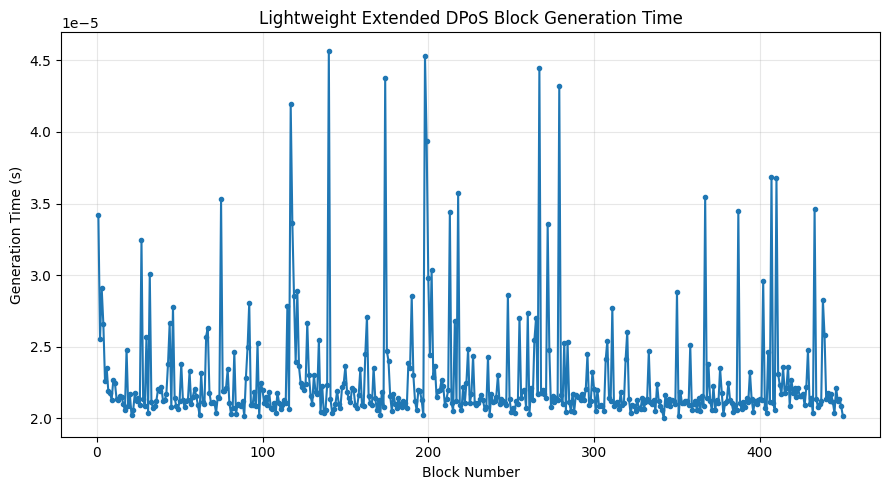

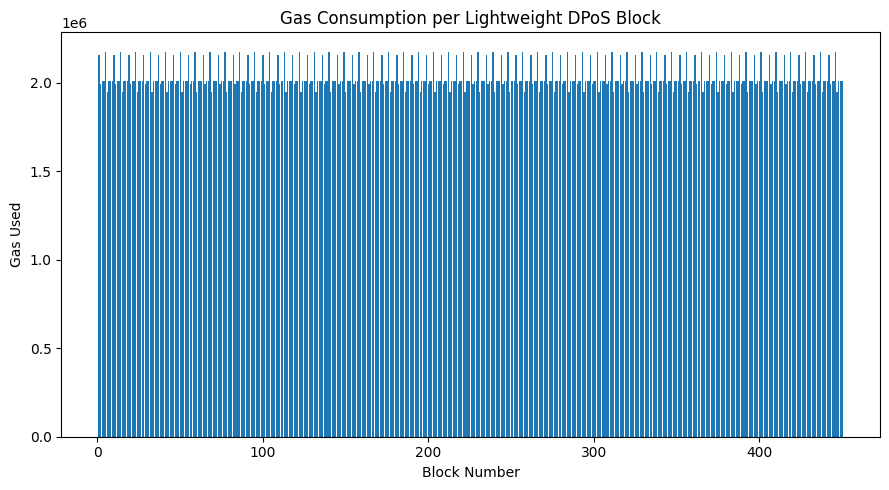

In [21]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 21 — Blockchain Performance Visualizations
# ═══════════════════════════════════════════════════════════════
if lightweight_blockchain.block_generation_times:
    plt.figure(figsize=(9, 5))

    plt.plot(
        range(
            1,
            len(lightweight_blockchain.block_generation_times) + 1
        ),
        lightweight_blockchain.block_generation_times,
        marker="o",
        markersize=3
    )

    plt.xlabel("Block Number")
    plt.ylabel("Generation Time (s)")
    plt.title(
        "Lightweight Extended DPoS Block Generation Time"
    )
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


gas_by_block = [
    block.gas_used
    for block in non_genesis_blocks
]

if gas_by_block:
    plt.figure(figsize=(9, 5))

    plt.bar(
        range(1, len(gas_by_block) + 1),
        gas_by_block
    )

    plt.xlabel("Block Number")
    plt.ylabel("Gas Used")
    plt.title("Gas Consumption per Lightweight DPoS Block")
    plt.tight_layout()
    plt.show()

In [22]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 22 — Combined Result Summary
# ═══════════════════════════════════════════════════════════════
print("Machine-Learning Results")
display(ml_results)

print("\nLightweight Blockchain Results")
display(blockchain_metrics)

print("\nExtended DPoS Delegate Results")
display(delegate_results)

print("\nPublic Transparency Portal")
display(transparency_portal_results.head())

Machine-Learning Results


,Metric,Value
0,Accuracy,0.999302
1,Precision,0.999895
2,Recall,0.999361
3,F1-Score,0.999628
4,ROC-AUC,0.999946
5,Training Time (s),145.553972
6,Prediction Time (s),0.619283



Lightweight Blockchain Results


,Metric,Value
0,Proof Type,Extended Delegated Proof of Stake (DPoS)
1,Projects Processed,1000
2,Total Transactions,9000
3,Total Blocks,450
4,Transaction Latency (s),0.0
5,Throughput (TPS),47648.167456
6,Average Block Generation Time (s),0.000023
7,Total Block Generation Time (s),0.010202
8,Chain Validation Time (s),0.003207
9,Average Gas Used,101644.888889



Extended DPoS Delegate Results


,Delegate,Stake,Reputation,Availability,Voting Score,Blocks Produced,Active Delegate
0,DELEGATE-07,91.381559,90.791610,97.580877,92.444438,90,True
1,DELEGATE-03,88.056985,94.651608,91.281136,90.680202,90,True
2,DELEGATE-01,88.697802,85.971961,98.585979,89.857685,90,True
3,DELEGATE-05,82.193256,95.569040,94.434142,88.654168,90,True
4,DELEGATE-02,84.868401,77.354434,99.756224,85.591776,90,True
5,DELEGATE-04,72.519297,84.269951,99.267650,81.394164,0,False
6,DELEGATE-06,61.361936,88.864620,90.638173,75.467988,0,False



Public Transparency Portal


,Project_ID,Allocated_Budget,Sent_to_City,Sent_to_Builder,Pending_at_City,Unreleased_Budget,Installment_Count,Utilization_Rate_Percent
0,CONT_AWD_SPE2DM26F2PH4_9700_SPE2DM20D9103_9700,500.80,500.80,500.80,0.0,0.0,3,100.0
1,CONT_AWD_47QSSC26F4R1B_4732_47QSHA21A000D_4732,189.34,189.34,189.34,0.0,0.0,3,100.0
2,CONT_AWD_SPE30026FXLL8_9700_SPE30025D4004_9700,18430.01,18430.01,18430.01,0.0,0.0,3,100.0
3,CONT_AWD_47QSSC26F3FRX_4732_47QSHA21A0009_4732,100.62,100.62,100.62,0.0,0.0,3,100.0
4,CONT_AWD_47QSSC26F3QKY_4732_47QSWA22D0009_4732,80.35,80.35,80.35,0.0,0.0,3,100.0


In [23]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 23 — Save and Download All Results
# ═══════════════════════════════════════════════════════════════
ml_results.to_csv(
    "ML_Results_GAN_USAspending_NoCV.csv",
    index=False
)

blockchain_metrics.to_csv(
    "Lightweight_DPoS_Blockchain_Metrics.csv",
    index=False
)

delegate_results.to_csv(
    "Extended_DPoS_Delegate_Results.csv",
    index=False
)

transparency_portal_results.to_csv(
    "Public_Transparency_Portal_Results.csv",
    index=False
)

processed_output_columns = [
    "Project_ID",
    "Project_Name",
    "Finance_Ministry",
    "Treasury",
    "City_Corporation",
    "Builder",
    "Budget",
    "Transaction_Amount",
    "Award_Type",
    "Project_Location",
    "Action_Date",
    "Risk_Label"
]

data[processed_output_columns].to_csv(
    "Processed_USAspending_Blockchain_Dataset.csv",
    index=False
)

print("Saved files:")
print("1. ML_Results_GAN_USAspending_NoCV.csv")
print("2. Lightweight_DPoS_Blockchain_Metrics.csv")
print("3. Extended_DPoS_Delegate_Results.csv")
print("4. Public_Transparency_Portal_Results.csv")
print("5. Processed_USAspending_Blockchain_Dataset.csv")

Saved files:
1. ML_Results_GAN_USAspending_NoCV.csv
2. Lightweight_DPoS_Blockchain_Metrics.csv
3. Extended_DPoS_Delegate_Results.csv
4. Public_Transparency_Portal_Results.csv
5. Processed_USAspending_Blockchain_Dataset.csv


In [24]:
# ═══════════════════════════════════════════════════════════════
# BLOCK 24 — Download Result Files
# ═══════════════════════════════════════════════════════════════
from google.colab import files

result_files = [
    "ML_Results_GAN_USAspending_NoCV.csv",
    "Lightweight_DPoS_Blockchain_Metrics.csv",
    "Extended_DPoS_Delegate_Results.csv",
    "Public_Transparency_Portal_Results.csv",
    "Processed_USAspending_Blockchain_Dataset.csv"
]

for output_file in result_files:
    files.download(output_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>